Title: Prediction of Forest-Related Carbon Emissions Using Machine Learning

Aim: To develop and evaluate machine learning models for predicting forest-related carbon emissions using historical carbon emission records and forest-related indicators such as tree cover extent and biomass stock, while identifying the most influential factors affecting carbon emissions.

Problem Statement: Forests play a crucial role in absorbing and storing carbon, helping to regulate the Earth's climate and mitigate the impacts of global warming. However, deforestation, forest degradation, and changes in forest cover can release significant amounts of stored carbon into the atmosphere, contributing to increased greenhouse gas emissions and climate change. Accurate prediction of forest-related carbon emissions can support environmental monitoring, sustainable forest management, and policy-making. This project utilizes machine learning techniques to analyze historical carbon emission data and forest-related indicators to predict carbon emissions and identify the key factors influencing emission levels.

#### Data Understanding

In [3]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [4]:
# Loading dataset

df = pd.read_csv("Subnational 2 carbon data.csv")

In [5]:
# Displaying first five rows

df.head()

,country,subnational1,subnational2,umd_tree_cover_density__threshold,umd_tree_cover_extent_2000__ha,whrc_aboveground_biomass_stock_2000__Mg,avg_whrc_aboveground_biomass_2000_Mg_ha-1,gfw_gross_emissions_co2e_all_gases__Mg_yr-1,gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1,gfw_net_flux_co2e__Mg_yr-1,...,gfw_gross_emissions_co2e_all_gases_2011__Mg,gfw_gross_emissions_co2e_all_gases_2012__Mg,gfw_gross_emissions_co2e_all_gases_2013__Mg,gfw_gross_emissions_co2e_all_gases_2014__Mg,gfw_gross_emissions_co2e_all_gases_2015__Mg,gfw_gross_emissions_co2e_all_gases_2016__Mg,gfw_gross_emissions_co2e_all_gases_2017__Mg,gfw_gross_emissions_co2e_all_gases_2018__Mg,gfw_gross_emissions_co2e_all_gases_2019__Mg,gfw_gross_emissions_co2e_all_gases_2020__Mg
0,India,Andaman and Nicobar,Nicobar Islands,0,172679,46631238,270,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,India,Andaman and Nicobar,Nicobar Islands,10,150112,46509073,310,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,India,Andaman and Nicobar,Nicobar Islands,15,149461,46432555,311,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,India,Andaman and Nicobar,Nicobar Islands,20,149054,46380652,311,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,India,Andaman and Nicobar,Nicobar Islands,25,148547,46318803,312,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Displaying last five rows

df.tail()

,country,subnational1,subnational2,umd_tree_cover_density__threshold,umd_tree_cover_extent_2000__ha,whrc_aboveground_biomass_stock_2000__Mg,avg_whrc_aboveground_biomass_2000_Mg_ha-1,gfw_gross_emissions_co2e_all_gases__Mg_yr-1,gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1,gfw_net_flux_co2e__Mg_yr-1,...,gfw_gross_emissions_co2e_all_gases_2011__Mg,gfw_gross_emissions_co2e_all_gases_2012__Mg,gfw_gross_emissions_co2e_all_gases_2013__Mg,gfw_gross_emissions_co2e_all_gases_2014__Mg,gfw_gross_emissions_co2e_all_gases_2015__Mg,gfw_gross_emissions_co2e_all_gases_2016__Mg,gfw_gross_emissions_co2e_all_gases_2017__Mg,gfw_gross_emissions_co2e_all_gases_2018__Mg,gfw_gross_emissions_co2e_all_gases_2019__Mg,gfw_gross_emissions_co2e_all_gases_2020__Mg
5323,India,West Bengal,Uttar Dinajpur,20,6110,753074,123,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5324,India,West Bengal,Uttar Dinajpur,25,5319,658079,124,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5325,India,West Bengal,Uttar Dinajpur,30,4269,535701,125,10556.0,21322.0,-10766.0,...,23573.0,14328.0,7982.0,18584.0,3052.0,303.0,3550.0,4792.0,1885.0,2610.0
5326,India,West Bengal,Uttar Dinajpur,50,2375,307859,130,7688.0,13406.0,-5718.0,...,16975.0,9484.0,4184.0,10994.0,2408.0,146.0,1950.0,3483.0,945.0,1673.0
5327,India,West Bengal,Uttar Dinajpur,75,177,33853,192,3087.0,1331.0,1755.0,...,3918.0,2653.0,540.0,997.0,166.0,0.0,104.0,201.0,127.0,209.0


In [7]:
# Display all column names in the dataset

df.columns

Index(['country', 'subnational1', 'subnational2',
       'umd_tree_cover_density__threshold', 'umd_tree_cover_extent_2000__ha',
       'whrc_aboveground_biomass_stock_2000__Mg',
       'avg_whrc_aboveground_biomass_2000_Mg_ha-1',
       'gfw_gross_emissions_co2e_all_gases__Mg_yr-1',
       'gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1',
       'gfw_net_flux_co2e__Mg_yr-1',
       'gfw_gross_emissions_co2e_all_gases_2001__Mg',
       'gfw_gross_emissions_co2e_all_gases_2002__Mg',
       'gfw_gross_emissions_co2e_all_gases_2003__Mg',
       'gfw_gross_emissions_co2e_all_gases_2004__Mg',
       'gfw_gross_emissions_co2e_all_gases_2005__Mg',
       'gfw_gross_emissions_co2e_all_gases_2006__Mg',
       'gfw_gross_emissions_co2e_all_gases_2007__Mg',
       'gfw_gross_emissions_co2e_all_gases_2008__Mg',
       'gfw_gross_emissions_co2e_all_gases_2009__Mg',
       'gfw_gross_emissions_co2e_all_gases_2010__Mg',
       'gfw_gross_emissions_co2e_all_gases_2011__Mg',
       '

In [8]:
# Checking number of rows and columns

df.shape

(5328, 30)

In [9]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5328 entries, 0 to 5327
Data columns (total 30 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   country                                                             5328 non-null   object 
 1   subnational1                                                        5328 non-null   object 
 2   subnational2                                                        5328 non-null   object 
 3   umd_tree_cover_density__threshold                                   5328 non-null   int64  
 4   umd_tree_cover_extent_2000__ha                                      5328 non-null   int64  
 5   whrc_aboveground_biomass_stock_2000__Mg                             5328 non-null   int64  
 6   avg_whrc_aboveground_biomass_2000_Mg_ha-1                           5328 non-null   int64  
 7   gfw_gross_emiss

In [10]:
# Displaying statistical summary

df.describe()

,umd_tree_cover_density__threshold,umd_tree_cover_extent_2000__ha,whrc_aboveground_biomass_stock_2000__Mg,avg_whrc_aboveground_biomass_2000_Mg_ha-1,gfw_gross_emissions_co2e_all_gases__Mg_yr-1,gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1,gfw_net_flux_co2e__Mg_yr-1,gfw_gross_emissions_co2e_all_gases_2001__Mg,gfw_gross_emissions_co2e_all_gases_2002__Mg,gfw_gross_emissions_co2e_all_gases_2003__Mg,...,gfw_gross_emissions_co2e_all_gases_2011__Mg,gfw_gross_emissions_co2e_all_gases_2012__Mg,gfw_gross_emissions_co2e_all_gases_2013__Mg,gfw_gross_emissions_co2e_all_gases_2014__Mg,gfw_gross_emissions_co2e_all_gases_2015__Mg,gfw_gross_emissions_co2e_all_gases_2016__Mg,gfw_gross_emissions_co2e_all_gases_2017__Mg,gfw_gross_emissions_co2e_all_gases_2018__Mg,gfw_gross_emissions_co2e_all_gases_2019__Mg,gfw_gross_emissions_co2e_all_gases_2020__Mg
count,5328.000000,5.328000e+03,5.328000e+03,5328.000000,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,...,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03,1.998000e+03
mean,28.125000,1.090189e+05,1.314008e+07,158.189377,6.088065e+04,1.187978e+05,-5.791715e+04,4.291815e+04,3.501100e+04,3.094920e+04,...,5.260772e+04,5.863660e+04,4.757704e+04,8.151774e+04,7.205290e+04,1.120871e+05,1.235514e+05,8.052042e+04,7.730858e+04,8.725684e+04
std,22.493429,2.314077e+05,2.644699e+07,73.115424,1.922512e+05,2.693074e+05,2.097905e+05,1.383087e+05,1.206693e+05,1.046488e+05,...,1.609476e+05,1.821685e+05,1.771061e+05,3.113153e+05,2.808891e+05,4.387183e+05,4.627741e+05,2.928833e+05,2.812910e+05,3.267484e+05
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,-3.169290e+05,-2.071571e+06,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,13.750000,2.870000e+02,3.293325e+04,126.000000,4.300000e+01,7.025000e+01,-3.928350e+04,3.925000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,2.800000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,22.500000,1.156600e+04,8.811550e+05,162.000000,5.430000e+02,1.913000e+03,-2.560000e+02,8.655000e+02,4.040000e+02,2.820000e+02,...,3.960000e+02,7.300000e+02,1.750000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,35.000000,1.255658e+05,1.382361e+07,208.000000,1.054600e+04,9.534150e+04,1.000000e+00,1.208075e+04,7.708500e+03,4.989750e+03,...,1.378425e+04,1.916750e+04,2.464750e+03,3.178750e+03,1.065750e+03,3.157000e+03,4.401750e+03,4.673500e+03,4.990750e+03,3.637250e+03
max,75.000000,4.908732e+06,1.855944e+08,336.000000,2.205811e+06,2.148801e+06,8.721450e+05,1.547889e+06,1.267463e+06,1.037931e+06,...,1.966473e+06,2.239128e+06,1.884601e+06,4.391403e+06,2.597387e+06,5.249074e+06,4.407564e+06,3.008909e+06,3.022366e+06,3.557083e+06


In [11]:
# Checking missing values

df.isnull().sum()

country                                                                  0
subnational1                                                             0
subnational2                                                             0
umd_tree_cover_density__threshold                                        0
umd_tree_cover_extent_2000__ha                                           0
whrc_aboveground_biomass_stock_2000__Mg                                  0
avg_whrc_aboveground_biomass_2000_Mg_ha-1                                0
gfw_gross_emissions_co2e_all_gases__Mg_yr-1                           3330
gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1    3330
gfw_net_flux_co2e__Mg_yr-1                                            3330
gfw_gross_emissions_co2e_all_gases_2001__Mg                           3330
gfw_gross_emissions_co2e_all_gases_2002__Mg                           3330
gfw_gross_emissions_co2e_all_gases_2003__Mg                           3330
gfw_gross_emissions_co2e_

In [12]:
# Filling missing numerical values with mean

df = df.fillna(df.mean(numeric_only=True))

In [13]:
# Verifying missing values after cleaning

df.isnull().sum()

country                                                               0
subnational1                                                          0
subnational2                                                          0
umd_tree_cover_density__threshold                                     0
umd_tree_cover_extent_2000__ha                                        0
whrc_aboveground_biomass_stock_2000__Mg                               0
avg_whrc_aboveground_biomass_2000_Mg_ha-1                             0
gfw_gross_emissions_co2e_all_gases__Mg_yr-1                           0
gfw_gross_cumulative_aboveground_belowground_co2_removals__Mg_yr-1    0
gfw_net_flux_co2e__Mg_yr-1                                            0
gfw_gross_emissions_co2e_all_gases_2001__Mg                           0
gfw_gross_emissions_co2e_all_gases_2002__Mg                           0
gfw_gross_emissions_co2e_all_gases_2003__Mg                           0
gfw_gross_emissions_co2e_all_gases_2004__Mg                     

#### Exploratory Data Analysis (EDA)

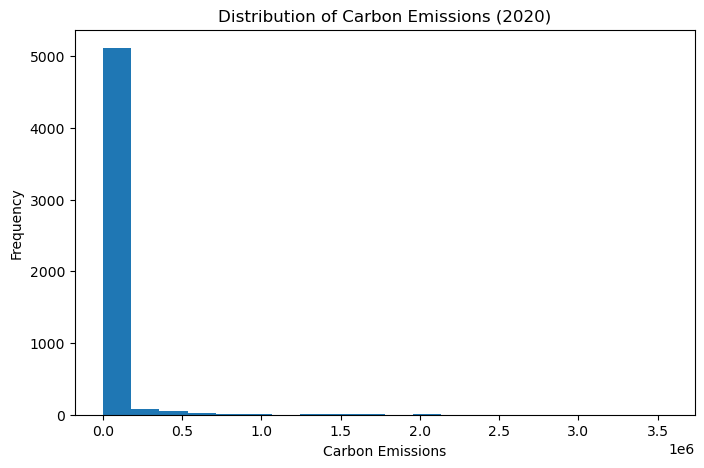

In [15]:
# Distribution of carbon emissions in 2020

plt.figure(figsize=(8,5))
plt.hist(
    df['gfw_gross_emissions_co2e_all_gases_2020__Mg'],
    bins=20
)
plt.title("Distribution of Carbon Emissions (2020)")
plt.xlabel("Carbon Emissions")
plt.ylabel("Frequency")
plt.show()

Interpretation: The histogram shows that most observations have relatively low carbon emission values, while only a few observations have very high emissions. The distribution is highly right-skewed, indicating the presence of extreme emission values. This suggests that forest-related carbon emissions are not evenly distributed across all observations.

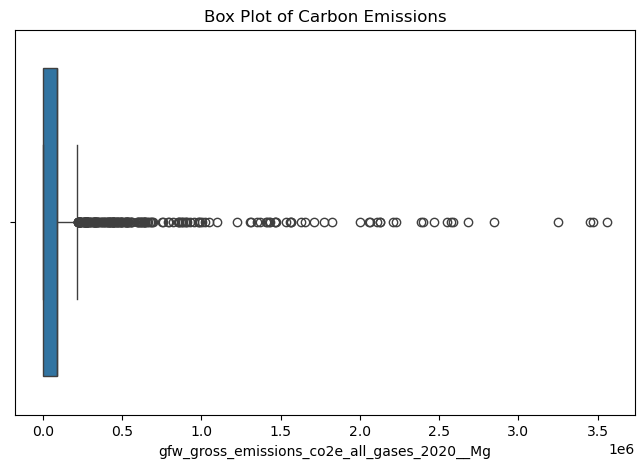

In [17]:
# Detecting outliers in carbon emissions

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df['gfw_gross_emissions_co2e_all_gases_2020__Mg']
)
plt.title("Box Plot of Carbon Emissions")
plt.show()

Interpretation: The box plot reveals a large number of outliers in the carbon emission data. Most observations are concentrated within a lower emission range, while several observations have exceptionally high emission values. This indicates significant variability in forest-related carbon emissions and confirms the presence of extreme cases in the dataset.

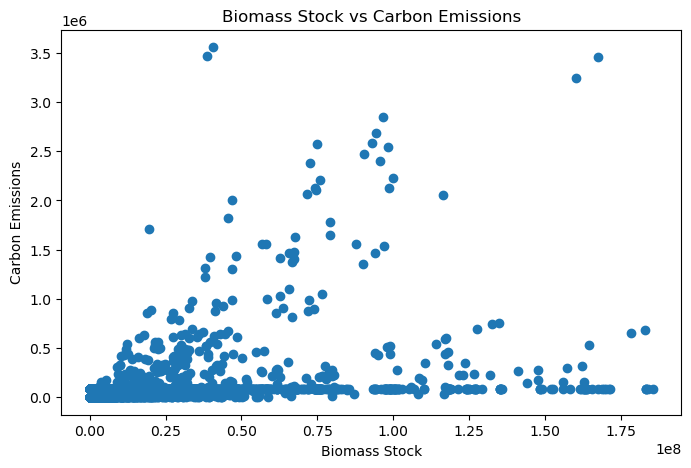

In [19]:
# Relationship between biomass stock and carbon emissions

plt.figure(figsize=(8,5))
plt.scatter(
    df['whrc_aboveground_biomass_stock_2000__Mg'],
    df['gfw_gross_emissions_co2e_all_gases_2020__Mg']
)
plt.xlabel("Biomass Stock")
plt.ylabel("Carbon Emissions")
plt.title("Biomass Stock vs Carbon Emissions")
plt.show()

Interpretation: The scatter plot shows the relationship between biomass stock and carbon emissions. While areas with higher biomass stock can have higher carbon emissions, the points are widely scattered, indicating a weak to moderate positive relationship. This suggests that biomass stock alone does not fully explain variations in carbon emissions.

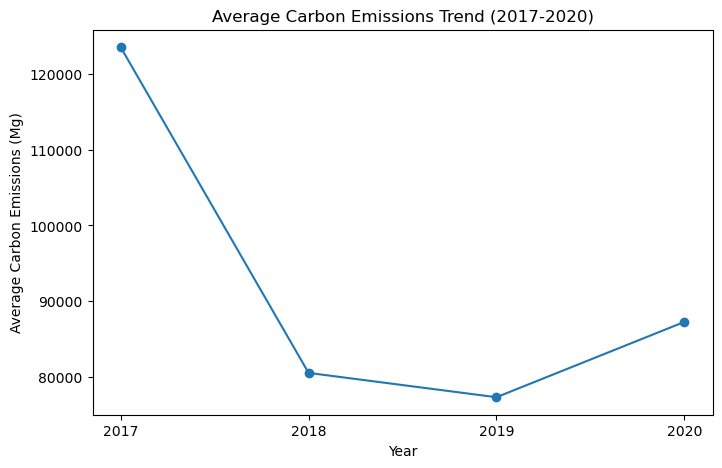

In [21]:
# Average carbon emissions across years

emissions = {
    '2017': df['gfw_gross_emissions_co2e_all_gases_2017__Mg'].mean(),
    '2018': df['gfw_gross_emissions_co2e_all_gases_2018__Mg'].mean(),
    '2019': df['gfw_gross_emissions_co2e_all_gases_2019__Mg'].mean(),
    '2020': df['gfw_gross_emissions_co2e_all_gases_2020__Mg'].mean()
}
plt.figure(figsize=(8,5))
plt.plot(
    list(emissions.keys()),
    list(emissions.values()),
    marker='o'
)
plt.title("Average Carbon Emissions Trend (2017-2020)")
plt.xlabel("Year")
plt.ylabel("Average Carbon Emissions (Mg)")
plt.show()

Interpretation: The line graph shows that average carbon emissions decreased sharply from 2017 to 2018 and continued to decline slightly in 2019. However, emissions increased again in 2020, although they remained lower than the 2017 level. Overall, the trend indicates a reduction in carbon emissions over the study period, followed by a partial increase in 2020.

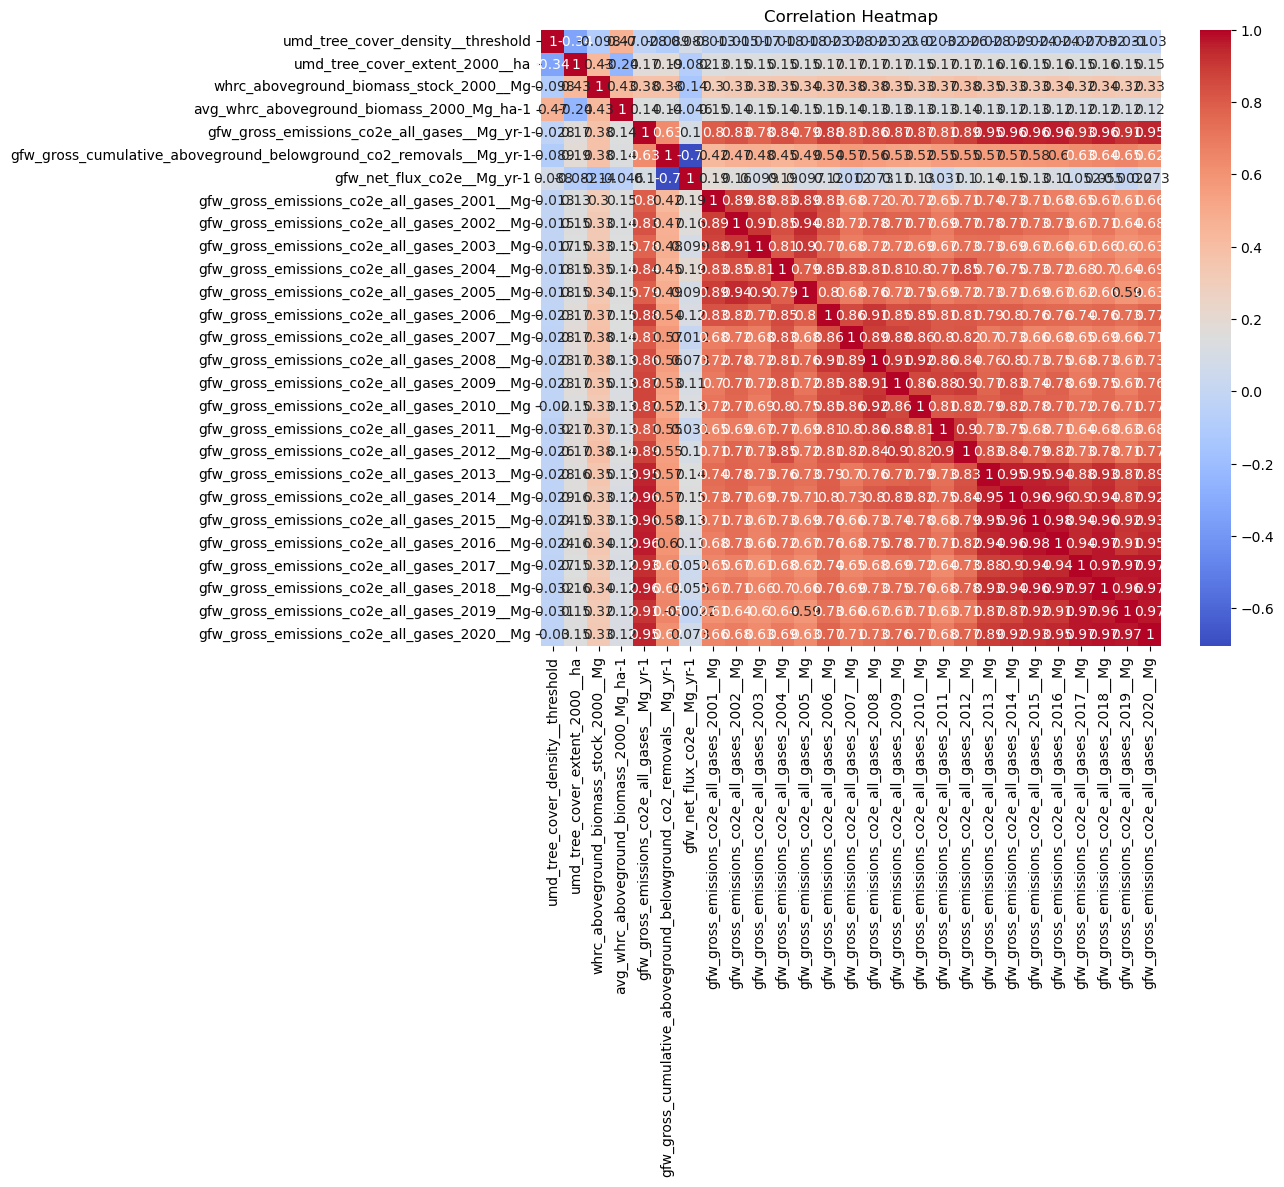

In [23]:
# Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

Interpretation: The heatmap shows the relationship between different forest and carbon-related variables. Dark red colors indicate strong positive correlations, meaning these variables tend to increase together, while blue colors indicate negative correlations. The yearly CO₂ emission variables have very high positive correlations with each other, suggesting that areas with high emissions in one year generally have high emissions in other years as well.

#### Target Variable Selection

In [26]:
# Display the target variable

target = 'gfw_gross_emissions_co2e_all_gases_2020__Mg'
print("Target Variable:")
print(target)

Target Variable:
gfw_gross_emissions_co2e_all_gases_2020__Mg


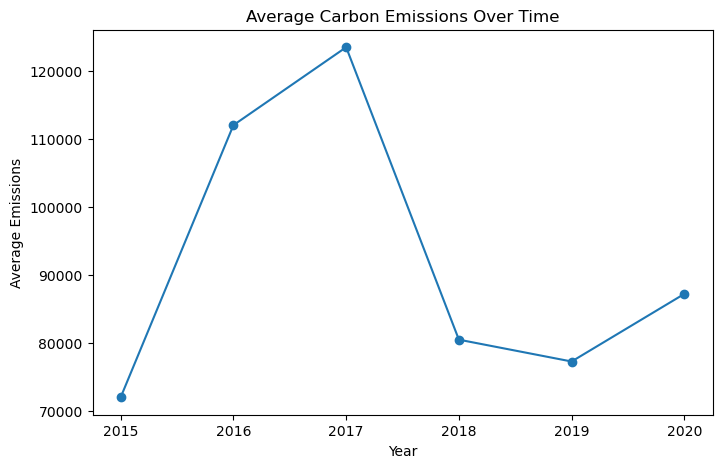

In [27]:
# Show yearly emissions trend

years = [
'gfw_gross_emissions_co2e_all_gases_2015__Mg',
'gfw_gross_emissions_co2e_all_gases_2016__Mg',
'gfw_gross_emissions_co2e_all_gases_2017__Mg',
'gfw_gross_emissions_co2e_all_gases_2018__Mg',
'gfw_gross_emissions_co2e_all_gases_2019__Mg',
'gfw_gross_emissions_co2e_all_gases_2020__Mg'
]

avg_emissions = []

for year in years:
    avg_emissions.append(
        df[year].mean()
    )

plt.figure(figsize=(8,5))
plt.plot(
    ['2015','2016','2017','2018','2019','2020'],
    avg_emissions,
    marker='o'
)
plt.title(
    "Average Carbon Emissions Over Time"
)
plt.xlabel("Year")
plt.ylabel("Average Emissions")
plt.show()

Interpretation: The dataset contains annual carbon emission measurements from 2001 to 2020. Since 2020 represents the most recent year available in the dataset, it is selected as the target variable. Historical emissions from previous years are used as input features to predict the carbon emission level in 2020. This follows a realistic forecasting approach where past observations are used to estimate future outcomes.mes.

#### Feature Selection
The correlation of each feature with the target variable (2020 carbon emissions) is calculated to identify the most influential predictors.

In [30]:
# Correlation of all features with target

target = 'gfw_gross_emissions_co2e_all_gases_2020__Mg'
target_corr = df.select_dtypes(
    include=np.number
).corr()[target]
target_corr = target_corr.sort_values(
    ascending=False
)
print(target_corr)

gfw_gross_emissions_co2e_all_gases_2020__Mg                           1.000000
gfw_gross_emissions_co2e_all_gases_2018__Mg                           0.974815
gfw_gross_emissions_co2e_all_gases_2019__Mg                           0.971662
gfw_gross_emissions_co2e_all_gases_2017__Mg                           0.971590
gfw_gross_emissions_co2e_all_gases__Mg_yr-1                           0.948651
gfw_gross_emissions_co2e_all_gases_2016__Mg                           0.945256
gfw_gross_emissions_co2e_all_gases_2015__Mg                           0.929601
gfw_gross_emissions_co2e_all_gases_2014__Mg                           0.918784
gfw_gross_emissions_co2e_all_gases_2013__Mg                           0.892365
gfw_gross_emissions_co2e_all_gases_2006__Mg                           0.773158
gfw_gross_emissions_co2e_all_gases_2012__Mg                           0.771424
gfw_gross_emissions_co2e_all_gases_2010__Mg                           0.766050
gfw_gross_emissions_co2e_all_gases_2009__Mg         

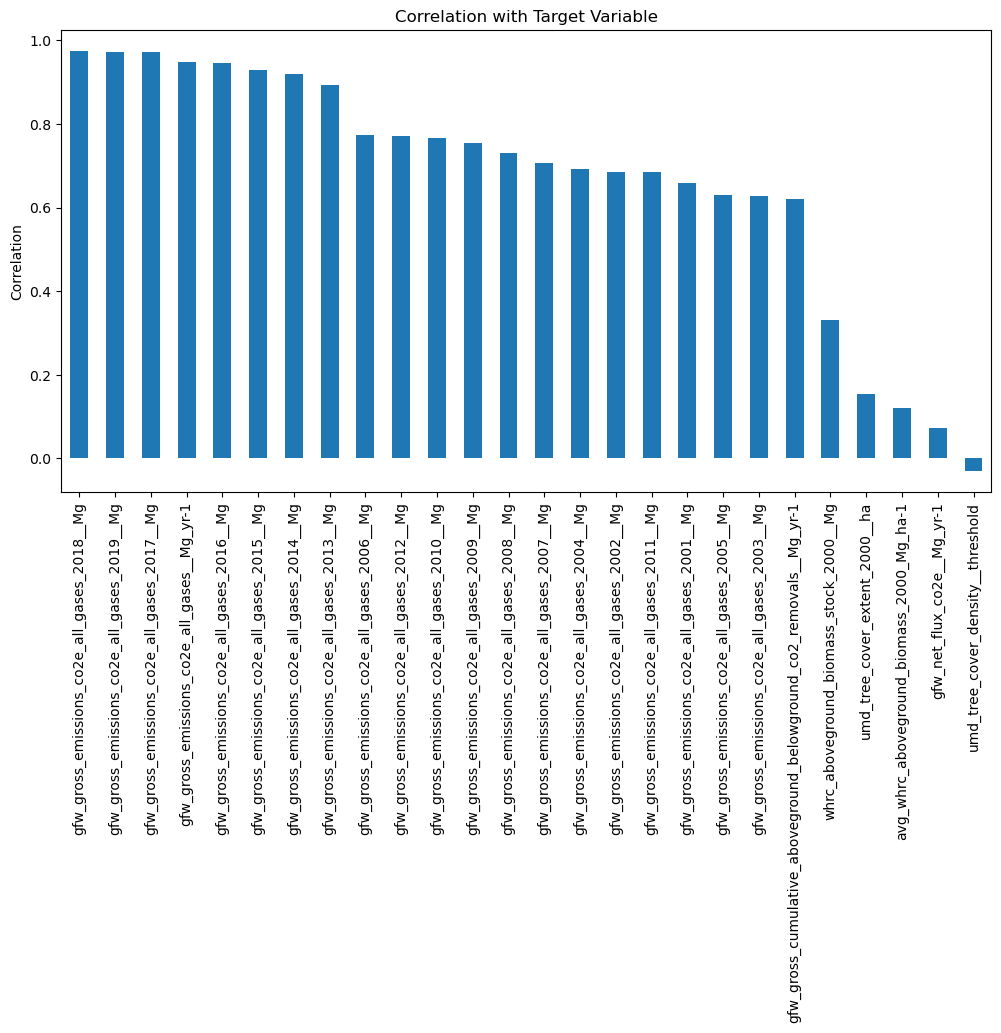

In [31]:
# Plot feature correlations with target

plt.figure(figsize=(12,6))
target_corr.drop(target).plot(
    kind='bar'
)
plt.title(
    "Correlation with Target Variable"
)
plt.ylabel("Correlation")
plt.show()

Interpretation: The graph displays the correlation between each feature and 2020 carbon emissions. Features with higher correlation values are considered more informative for prediction and are selected for model training.

#### Feature Selection Justification
The top correlated features are selected because they provide the most predictive information about future carbon emissions.

In [34]:
top_features = target_corr.abs().sort_values(
    ascending=False
).index[1:8]

print("Selected Features:")

for i, feature in enumerate(top_features,1):
    print(i, feature)

Selected Features:
1 gfw_gross_emissions_co2e_all_gases_2018__Mg
2 gfw_gross_emissions_co2e_all_gases_2019__Mg
3 gfw_gross_emissions_co2e_all_gases_2017__Mg
4 gfw_gross_emissions_co2e_all_gases__Mg_yr-1
5 gfw_gross_emissions_co2e_all_gases_2016__Mg
6 gfw_gross_emissions_co2e_all_gases_2015__Mg
7 gfw_gross_emissions_co2e_all_gases_2014__Mg


In [35]:
features = list(top_features)
X = df[features]
y = df[
    'gfw_gross_emissions_co2e_all_gases_2020__Mg'
]
print(X.head())

   gfw_gross_emissions_co2e_all_gases_2018__Mg  \
0                                  80520.41992   
1                                  80520.41992   
2                                  80520.41992   
3                                  80520.41992   
4                                  80520.41992   

   gfw_gross_emissions_co2e_all_gases_2019__Mg  \
0                                 77308.579079   
1                                 77308.579079   
2                                 77308.579079   
3                                 77308.579079   
4                                 77308.579079   

   gfw_gross_emissions_co2e_all_gases_2017__Mg  \
0                                123551.400901   
1                                123551.400901   
2                                123551.400901   
3                                123551.400901   
4                                123551.400901   

   gfw_gross_emissions_co2e_all_gases__Mg_yr-1  \
0                                 60880.653654 

Interpretation: 
The selected features were chosen using correlation analysis. Historical carbon emission values and forest-related indicators such as biomass stock and tree cover are expected to influence future carbon emissions and therefore serve as meaningful predictors.

#### Train-Test Split

In [38]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4262, 7)
Testing Shape: (1066, 7)


#### Decision Tree

In [40]:
# Train Decision Tree Regressor model

dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)
dt.fit(
    X_train,
    y_train
)
dt_pred = dt.predict(
    X_test
)

#### Random Forest

In [42]:
# Train Random Forest Regressor model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)
rf_pred = rf.predict(
    X_test
)

#### XGBoost

In [44]:
# Train XGBoost Regressor model

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(
    X_train,
    y_train
)
xgb_pred = xgb.predict(
    X_test
)

#### Model Comparison 

In [46]:
# Compare performance of all machine learning models

results = pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'MAE':[

        mean_absolute_error(
            y_test,
            dt_pred
        ),
        mean_absolute_error(
            y_test,
            rf_pred
        ),
        mean_absolute_error(
            y_test,
            xgb_pred
        )
    ],

    'RMSE':[
        np.sqrt(
            mean_squared_error(
                y_test,
                dt_pred
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                rf_pred
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                xgb_pred
            )
        )
    ],

    'R2 Score':[
        r2_score(
            y_test,
            dt_pred
        ),
        r2_score(
            y_test,
            rf_pred
        ),
        r2_score(
            y_test,
            xgb_pred
        )
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,7020.013815,43389.894676,0.944869
1,Random Forest,5353.060481,35788.966431,0.962493
2,XGBoost,5225.853966,32943.135910,0.968220


#### Model Comparison Graph

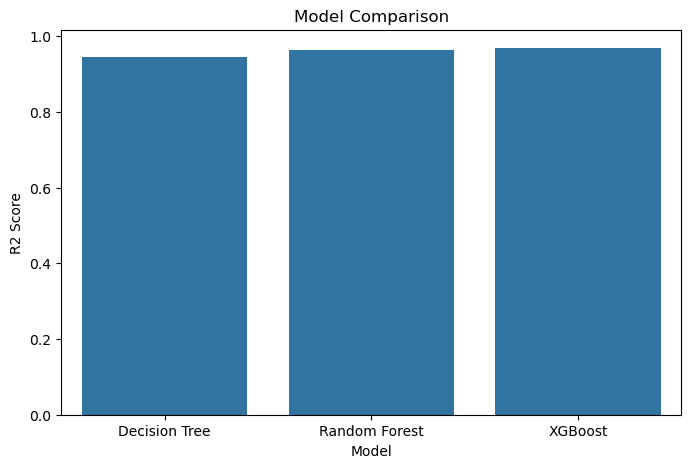

In [48]:
# Visualize the comparison of different machine learning models

plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)
plt.title(
    'Model Comparison'
)
plt.show()

Interpretation: Three machine learning models were evaluated for carbon emission prediction. XGBoost achieved the highest predictive performance and was selected as the final model for further analysis.

#### Final Model (XGBoost)

In [51]:
# Select the XGBoost model as the final model

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(
    X_train,
    y_train
)
y_pred = final_model.predict(
    X_test
)

#### Evaluation

In [53]:
# Calculate MAE, RMSE and R² score

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        y_pred
    )
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
)
print(
    "R2 Score:",
    r2_score(
        y_test,
        y_pred
    )
)

MAE: 5225.853965523214
RMSE: 32943.13590996885
R2 Score: 0.9682203826268057


#### Actual vs Predicted

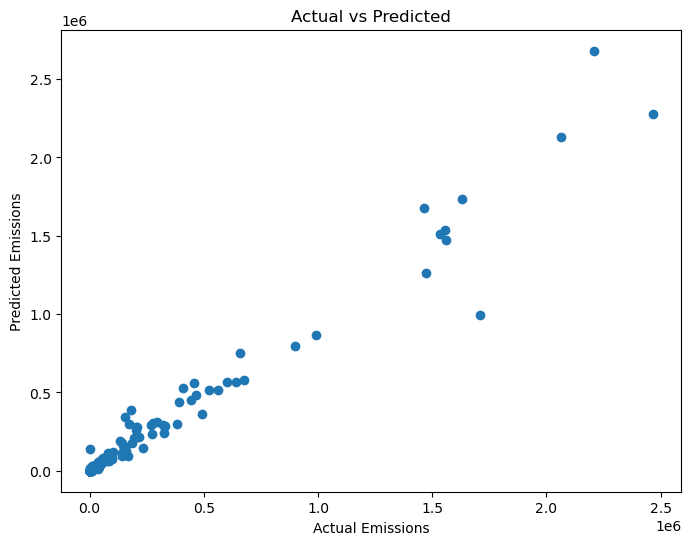

In [55]:
# Compare actual and predicted flood probability values

plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred
)
plt.xlabel(
    "Actual Emissions"
)
plt.ylabel(
    "Predicted Emissions"
)
plt.title(
    "Actual vs Predicted"
)
plt.show()

Interpretation: The Actual vs Predicted plot demonstrates the prediction capability of the XGBoost model. Points closer to the ideal diagonal line indicate higher prediction accuracy.

#### Feature Importance

In [58]:
# Calculate feature importance scores

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':
    final_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,gfw_gross_emissions_co2e_all_gases_2018__Mg,0.456967
1,gfw_gross_emissions_co2e_all_gases_2019__Mg,0.248820
2,gfw_gross_emissions_co2e_all_gases_2017__Mg,0.179662
4,gfw_gross_emissions_co2e_all_gases_2016__Mg,0.066544
3,gfw_gross_emissions_co2e_all_gases__Mg_yr-1,0.028325
6,gfw_gross_emissions_co2e_all_gases_2014__Mg,0.014759
5,gfw_gross_emissions_co2e_all_gases_2015__Mg,0.004923


#### Feature Importance Graph

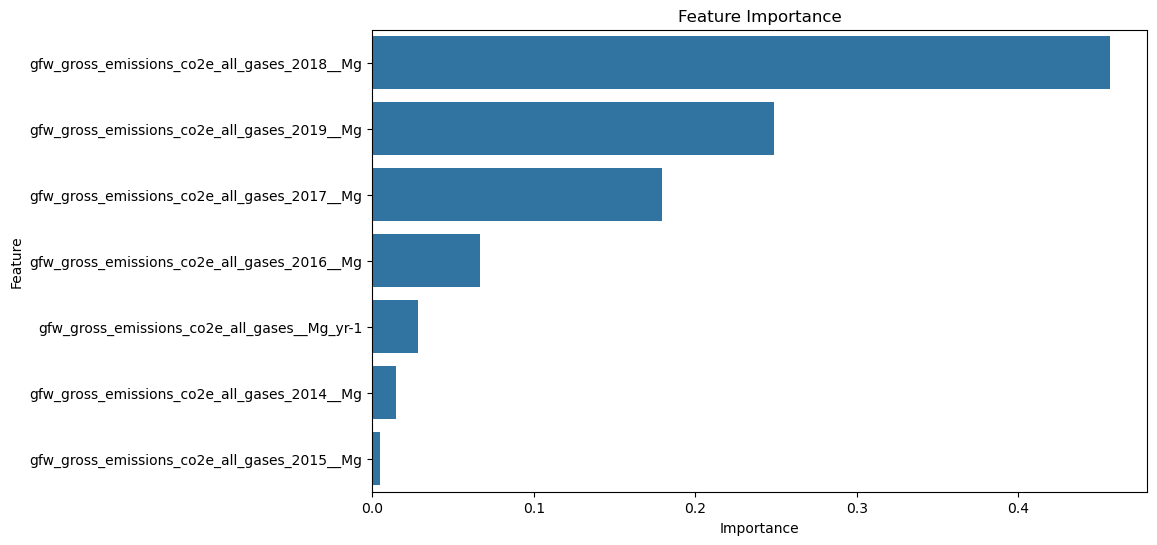

In [60]:
# Feature Importance Graph

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title(
    "Feature Importance"
)
plt.show()

Interpretation: The feature importance analysis identifies the most influential variables affecting carbon emission prediction. Features with higher importance values contribute more significantly to model decisions.

#### Feature Removal Experiment

In [63]:
# Removing Top 2 features

top2 = importance.head(2)['Feature'].tolist()
print("Removed Features:", top2)
X_new = X.drop(columns=top2)

Removed Features: ['gfw_gross_emissions_co2e_all_gases_2018__Mg', 'gfw_gross_emissions_co2e_all_gases_2019__Mg']


In [64]:
# Split data again
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)

# Train XGBoost again
model2 = XGBRegressor(
    random_state=42
)

model2.fit(
    X_train2,
    y_train2
)

# Predictions
pred2 = model2.predict(X_test2)

# Metrics
original_r2 = r2_score(y_test, y_pred)
new_r2 = r2_score(y_test2, pred2)

original_mae = mean_absolute_error(y_test, y_pred)
new_mae = mean_absolute_error(y_test2, pred2)

original_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
new_rmse = np.sqrt(mean_squared_error(y_test2, pred2))

# Comparison Table
comparison = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'RMSE'],
    'Original Model': [
        round(original_r2, 4),
        round(original_mae, 4),
        round(original_rmse, 4)
    ],
    'After Removing Top 2 Features': [
        round(new_r2, 4),
        round(new_mae, 4),
        round(new_rmse, 4)
    ]
})

comparison

,Metric,Original Model,After Removing Top 2 Features
0,R² Score,0.9682,0.9592
1,MAE,5225.8540,6268.5086
2,RMSE,32943.1359,37320.8150


Interpretation: After removing the two most important features, the model's R² score decreased from 0.9682 to 0.9592, while both MAE and RMSE increased. This indicates that the removed features play an important role in predicting carbon emissions and contribute to the model's accuracy. However, the relatively small decline in performance suggests that other features in the dataset also provide substantial predictive information.nce.

Conclusion: This project successfully developed machine learning models to predict forest-related carbon emissions using historical emission records and forest-related indicators. Through data preprocessing, exploratory data analysis, target variable selection, correlation analysis, feature selection, model training, and performance evaluation, important relationships between forest characteristics and carbon emissions were identified. Three machine learning models—Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor—were trained and compared. Among them, the XGBoost Regressor achieved the best performance with an R² score of 0.9682, demonstrating excellent predictive capability. Feature importance analysis highlighted the most influential predictors contributing to carbon emission estimation. Furthermore, a feature removal experiment showed that removing the top two important features resulted in a decline in model performance, confirming their significance in accurate carbon emission prediction. The findings demonstrate that machine learning techniques can effectively model and predict forest-related carbon emissions, providing valuable insights for environmental monitoring, forest conservation, carbon management, and climate change mitigation strategies.